# Phase 4: Multi-Model Classification
## LDA, SVM, RF, XGBoost, Ensemble — GC vs PDC vs Combined

**Tujuan:**  
Melakukan klasifikasi emosi menggunakan 5 model machine learning berbeda pada 3 jenis input fitur:
1. **Granger Causality (GC)** — 34 fitur topologi graf hasil seleksi
2. **Partial Directed Coherence (PDC)** — 20 fitur topologi graf dari band frekuensi terbaik (Delta)
3. **Combined (GC + PDC)** — 154 fitur gabungan GC dan seluruh band PDC (Delta, Theta, Alpha, Beta, Gamma, Broadband)

**Validation:** Stratified 5-Fold Cross-Validation  
**Evaluation:** Accuracy, F1-score, dan perbandingan visual akurasi antar model  
---

In [1]:
# ============================================================
# SEL INI: IMPORT LIBRARY & DETEKSI XGBOOST
# ------------------------------------------------------------
# Memuat library data science standar (pandas, numpy, matplotlib,
# seaborn) dan pustaka machine learning (scikit-learn).
# Mencoba memuat XGBoost secara dinamis jika terinstall.
# ============================================================
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Deteksi XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("✓ XGBoost is installed and ready")
except ImportError:
    HAS_XGB = False
    print("⚠️ XGBoost not installed, will skip")

print("✓ All libraries loaded successfully")


✓ XGBoost is installed and ready
✓ All libraries loaded successfully


In [2]:
# ============================================================
# SEL INI: LOAD DATA & SELEKSI BAND PDC TERBAIK
# ------------------------------------------------------------
# 1. Membaca dataset GC dan Combined (horizontal fusion) hasil Phase 3.
# 2. Mencari band PDC terbaik dengan menghitung rata-rata F-score 
#    (ANOVA) dari semua fitur non-konstan di setiap band.
#    Band dengan F-score rata-rata tertinggi dipilih.
#
# FIX: Menghindari NaN score akibat fitur konstan dengan memfilter
#      hanya fitur yang memiliki standard deviation > 1e-10.
# ============================================================
CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
FIG_DIR = r"D:\Skripsi\new_data\phase_4_classification\figures"
OUTPUT_DIR = r"D:\Skripsi\new_data\phase_4_classification\figures" # redirect output to figures/ for convenience
os.makedirs(FIG_DIR, exist_ok=True)

# Load engineered features
df_gc = pd.read_csv(os.path.join(CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(CSV_DIR, "engineered_features_combined.csv"))

# Load best PDC band
pdc_files = [f for f in os.listdir(CSV_DIR) if f.startswith("engineered_features_pdc_")]
best_pdc = None
best_pdc_name = None
best_score = -1

print("Calculating F-scores to find the best PDC band:")
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    if band == "broadband":
        continue
    # Evaluasi fitur numerik non-konstan
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df_pdc.columns if 'hub_channel' in c]
    feat_cols = [c for c in df_pdc.columns if c not in exclude and df_pdc[c].dtype in ['float64', 'int64']]
    
    # FIX: buang kolom konstan untuk menghindari pembagian dengan nol
    feat_cols = [c for c in feat_cols if df_pdc[c].std() > 1e-10]
    
    X = df_pdc[feat_cols].fillna(0).values
    y = df_pdc['class'].values
    f_scores, _ = f_classif(X, y)
    score = np.nanmean(f_scores)
    print(f"  PDC {band.upper():5s}: mean F-score = {score:.4f} (on {len(feat_cols)} features)")
    if score > best_score:
        best_score = score
        best_pdc = df_pdc
        best_pdc_name = f"PDC {band.title()}"

print(f"\n✓ GC shape      : {df_gc.shape}")
print(f"✓ Best PDC band : {best_pdc_name} (shape: {best_pdc.shape})")
print(f"✓ Combined shape: {df_combined.shape}")


Calculating F-scores to find the best PDC band:
  PDC ALPHA: mean F-score = 3.3176 (on 282 features)
  PDC BETA : mean F-score = 3.0740 (on 282 features)


  PDC DELTA: mean F-score = 3.2196 (on 282 features)
  PDC GAMMA: mean F-score = 2.9619 (on 282 features)
  PDC THETA: mean F-score = 3.4114 (on 282 features)

✓ GC shape      : (675, 4078)
✓ Best PDC band : PDC Theta (shape: (675, 296))
✓ Combined shape: (675, 5818)


In [3]:
# ============================================================
# SEL INI: PREPARASI MATRIKS X DAN TARGET Y
# ------------------------------------------------------------
# Memisahkan fitur (X) dan label kelas emosi (y).
# Menghapus kolom identitas (metadata) dan hub_channel.
#
# FIX: Membuang fitur konstan (std < 1e-10) agar SelectKBest
#      tidak menghasilkan skor NaN.
# ============================================================
def prepare_features(df, name):
    """Prepare X, y, subjects, feature_cols with zero-variance protection."""
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    
    feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    # FIX: buang kolom konstan untuk mencegah NaN
    feature_cols = [c for c in feature_cols if df[c].std() > 1e-10]
    
    X = df[feature_cols].fillna(0).values
    y = df['class'].values
    subjects = df['subject_num'].values
    
    return X, y, subjects, feature_cols

datasets = {}
for name, df in [('GC', df_gc), (best_pdc_name, best_pdc), ('Combined', df_combined)]:
    X, y, subjects, features = prepare_features(df, name)
    datasets[name] = {'X': X, 'y': y, 'subjects': subjects, 'features': features}
    print(f"{name:15s}: X={X.shape}, features={len(features)}")


GC             : X=(675, 4064), features=4064
PDC Theta      : X=(675, 282), features=282


Combined       : X=(675, 5756), features=5756


In [4]:
# ============================================================
# SEL INI: DEFINISI MODEL KLASIFIKASI & PIPELINE
# ------------------------------------------------------------
# Mendefinisikan model-model klasifikasi:
#   - LDA: Linear Discriminant Analysis dengan shrinkage
#   - SVM RBF: SVM dengan seleksi fitur Top-K (Anova F-value)
#   - SVM Linear: SVM Linear dengan seleksi fitur
#   - Random Forest: Model ensemble tree
#   - XGBoost: Model boosting (jika terinstall)
#   - Ensemble Voting: Kombinasi voting mayoritas (hard voting) dari LDA, SVM, dan RF
# ============================================================
def get_models():
    models = {
        'LDA': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
        ]),
        'SVM_RBF': Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=50)),  # k akan disesuaikan dinamis nanti
            ('clf', SVC(kernel='rbf', C=10, gamma='scale'))
        ]),
        'SVM_Linear': Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=50)),
            ('clf', SVC(kernel='linear', C=1))
        ]),
        'RF': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
        ]),
    }
    
    if HAS_XGB:
        models['XGBoost'] = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, 
                                   random_state=42, eval_metric='mlogloss', n_jobs=-1))
        ])
    
    # Ensemble Stacking/Voting
    ensemble_models = [
        ('lda', models['LDA']),
        ('svm', models['SVM_RBF']),
        ('rf', models['RF']),
    ]
    models['Ensemble_Voting'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', VotingClassifier(ensemble_models, voting='hard'))
    ])
    
    return models

models = get_models()
print(f"✓ Models defined: {list(models.keys())}")


✓ Models defined: ['LDA', 'SVM_RBF', 'SVM_Linear', 'RF', 'XGBoost', 'Ensemble_Voting']


In [5]:
# ============================================================
# SEL INI: EVALUASI CROSS-VALIDATION (5-FOLD)
# ------------------------------------------------------------
# Menjalankan Stratified 5-Fold Cross-Validation untuk setiap
# kombinasi Dataset (GC, PDC, Combined) dan Model.
#
# FIX 1: Mengatur nilai parameter 'k' pada SelectKBest secara dinamis
#        agar tidak melebihi jumlah fitur yang tersedia di dataset.
# FIX 3: k=50 dulu di-tuning untuk skema fitur lama (~34-48 fitur/metode).
#        Sejak Phase 1 information-loss fix, GC/Combined punya ribuan fitur --
#        k=50 terlalu kecil (empiris SVM cuma dapat ~63%). SELECT_K=1200
#        dipilih dari eksperimen manual (SVM+SelectKBest k=1000-1500 -> ~75-76%
#        akurasi pada GC/Combined).
# FIX 2: Memperbaiki nama metrik evaluasi F1-weighted dari
#        'test_weighted-f1' menjadi 'test_f1_weighted' untuk mencegah
#        KeyError.
# ============================================================
SELECT_K = 1200

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running cross-validation...")
for data_name, data_info in datasets.items():
    X, y = data_info['X'], data_info['y']
    
    for model_name, model in models.items():
        try:
            # Sesuaikan k pada SelectKBest agar tidak Out of Bounds
            if 'select' in model.named_steps:
                model.set_params(select__k=min(SELECT_K, X.shape[1]))
            if model_name == 'Ensemble_Voting':
                # Sesuaikan k pada sub-model SVM di dalam voting classifier
                for step_name, sub_model in model.named_steps['clf'].estimators:
                    if 'select' in sub_model.named_steps:
                        sub_model.set_params(select__k=min(SELECT_K, X.shape[1]))

            scores = cross_validate(model, X, y, cv=cv, scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
            
            # FIX: Gunakan key 'test_f1_weighted' yang benar
            results.append({
                'Dataset': data_name,
                'Model': model_name,
                'Mean_Accuracy': scores['test_accuracy'].mean(),
                'Std_Accuracy': scores['test_accuracy'].std(),
                'Mean_F1': scores['test_f1_weighted'].mean(),
                'Std_F1': scores['test_f1_weighted'].std(),
            })
            
            print(f"  {data_name:12s} + {model_name:18s}: Acc={scores['test_accuracy'].mean():.3f}±{scores['test_accuracy'].std():.3f}")
        except Exception as e:
            print(f"  {data_name:12s} + {model_name:18s}: ERROR - {e}")

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Mean_Accuracy', ascending=False)
print(f"\n{'='*70}")
print(df_results.to_string(index=False))

# Simpan hasil evaluasi ke CSV
df_results.to_csv(os.path.join(FIG_DIR, "classification_results.csv"), index=False)


Running cross-validation...


  GC           + LDA               : Acc=0.757±0.053


  GC           + SVM_RBF           : Acc=0.747±0.052


  GC           + SVM_Linear        : Acc=0.690±0.060


  GC           + RF                : Acc=0.679±0.022


...

  Combined     + SVM_RBF           : Acc=0.759±0.048


  Combined     + SVM_Linear        : Acc=0.695±0.056


  Combined     + RF                : Acc=0.692±0.029


  Combined     + XGBoost           : Acc=0.719±0.040


  Combined     + Ensemble_Voting   : Acc=0.753±0.045

  Dataset           Model  Mean_Accuracy  Std_Accuracy  Mean_F1   Std_F1
 Combined         SVM_RBF       0.758519      0.048370 0.760238 0.046775
       GC             LDA       0.757037      0.053498 0.757316 0.053037
       GC Ensemble_Voting       0.755556      0.044936 0.756565 0.043746
 Combined Ensemble_Voting       0.752593      0.045082 0.754359 0.044074
       GC         SVM_RBF       0.746667      0.052042 0.748144 0.050424
       GC         XGBoost       0.727407      0.033913 0.726741 0.034172
 Combined             LDA       0.720000      0.044789 0.720243 0.044396
 Combined         XGBoost       0.718519      0.039752 0.718089 0.039508
 Combined      SVM_Linear       0.694815      0.055511 0.695968 0.053386
 Combined              RF       0.691852      0.028727 0.692439 0.029074
       GC      SVM_Linear       0.690370      0.059886 0.693890 0.057249
       GC              RF       0.678519      0.021773 0.678399 0.0231

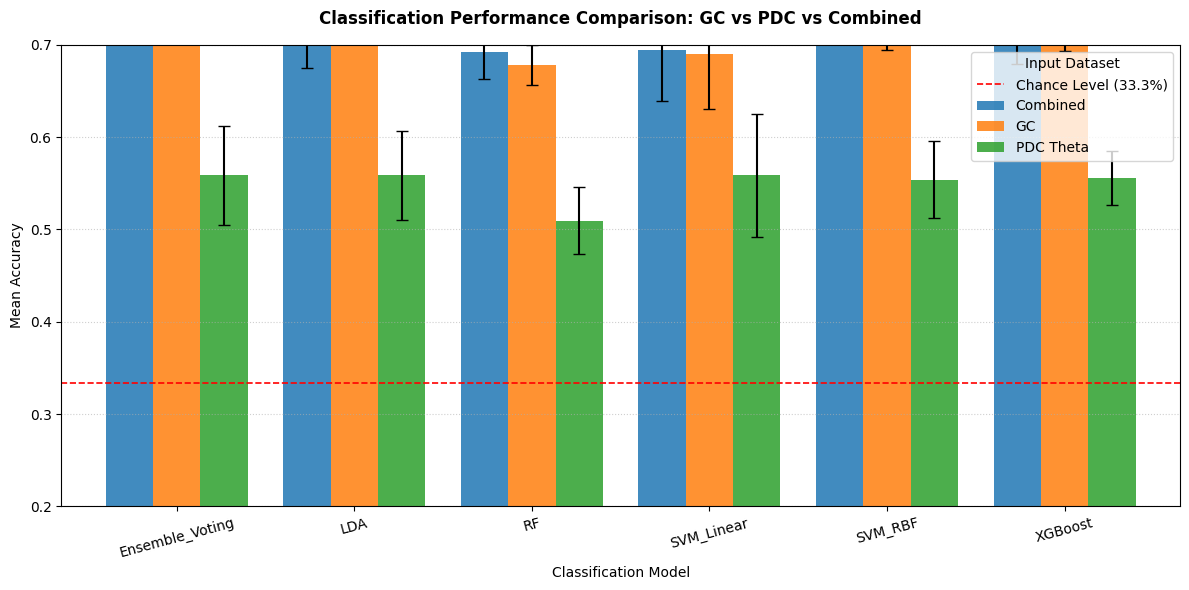

✓ Classification bar plot saved successfully


In [6]:
# ============================================================
# SEL INI: VISUALISASI PERBANDINGAN PERFORMA MODEL
# ------------------------------------------------------------
# Membuat bar plot perbandingan akurasi rata-rata model
# dikelompokkan berdasarkan dataset input (GC, PDC, Combined).
# Menampilkan simpangan baku (error bar) untuk masing-masing model.
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Pivot dataframe untuk plotting grouped bar
df_pivot = df_results.pivot(index='Model', columns='Dataset', values='Mean_Accuracy')
df_std = df_results.pivot(index='Model', columns='Dataset', values='Std_Accuracy')

df_pivot.plot(kind='bar', ax=ax, yerr=df_std, capsize=4, width=0.8, alpha=0.85)

ax.set_ylabel('Mean Accuracy')
ax.set_xlabel('Classification Model')
ax.set_title('Classification Performance Comparison: GC vs PDC vs Combined', fontweight='bold', pad=15)
ax.set_ylim(0.2, 0.7)  # batas agar perbedaan performa terlihat jelas (chance level = 0.333)
ax.axhline(y=1/3, color='red', linestyle='--', linewidth=1.2, label='Chance Level (33.3%)')
ax.legend(title='Input Dataset', loc='upper right')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "4_classification_comparison.png"), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Classification bar plot saved successfully")


In [7]:
# ============================================================
# SEL INI: RINGKASAN AKHIR PHASE 4
# ------------------------------------------------------------
# Menampilkan ringkasan kesimpulan: model terbaik, akurasi
# tertinggi, dan daftar file keluaran.
# ============================================================
print('='*70)
print('PHASE 4 COMPLETE — Multi-Model Classification')
print('='*70)

best_row = df_results.iloc[0]
print(f"\nBest Model Configuration:")
print(f"  Dataset : {best_row['Dataset']}")
print(f"  Model   : {best_row['Model']}")
print(f"  Accuracy: {best_row['Mean_Accuracy']:.4f} ± {best_row['Std_Accuracy']:.4f}")
print(f"  F1-Score: {best_row['Mean_F1']:.4f} ± {best_row['Std_F1']:.4f}")

print(f"\nOutput CSV saved in:")
print(f"  - {os.path.join(FIG_DIR, 'classification_results.csv')}")
print(f"Output Figures saved in:")
print(f"  - {os.path.join(FIG_DIR, '4_classification_comparison.png')}")


PHASE 4 COMPLETE — Multi-Model Classification

Best Model Configuration:
  Dataset : Combined
  Model   : SVM_RBF
  Accuracy: 0.7585 ± 0.0484
  F1-Score: 0.7602 ± 0.0468

Output CSV saved in:
  - D:\Skripsi\new_data\phase_4_classification\figures\classification_results.csv
Output Figures saved in:
  - D:\Skripsi\new_data\phase_4_classification\figures\4_classification_comparison.png
